In [1]:
import torch


def apply_masks(x, masks, concat=True):
    """
    :param x: tensor of shape [B (batch-size), N (num-patches), D (feature-dim)]
    :param masks: list of tensors of shape [B, K] containing indices of K patches in [N] to keep
    """
    all_x = []
    for m in masks:
        mask_keep = m.unsqueeze(-1).repeat(1, 1, x.size(-1))
        all_x += [torch.gather(x, dim=1, index=mask_keep)]
    if not concat:
        return all_x

    return torch.cat(all_x, dim=0)

In [2]:
def get_complement_masks(masks, n):
    """
    masks = [b, k] contains k patch indices in [0, n)
    Returns complement = [b, n-k] containing the remaining indices
    """
    b, k = masks.shape
    device = masks.device

    # Start with all indices marked as "keep" (True)
    keep = torch.ones(b, n, dtype=torch.bool, device=device)
    # Mark the masked indices as False (these are the ones we want to remove)
    keep.scatter_(1, masks, False)

    # The complement indices are those still marked True
    complement = torch.arange(n, device=device).unsqueeze(0).expand(b, -1)
    complement_indices = complement[keep].view(b, n - k)

    return complement_indices

In [3]:
import torch

x = torch.arange(1, 28).reshape(3, 3, 3)

print(x)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9]],

        [[10, 11, 12],
         [13, 14, 15],
         [16, 17, 18]],

        [[19, 20, 21],
         [22, 23, 24],
         [25, 26, 27]]])


In [4]:
y = torch.tensor([
    [0,1], [0,2], [1,0]
])
y.shape

torch.Size([3, 2])

In [5]:
y = [y]

In [6]:
y

[tensor([[0, 1],
         [0, 2],
         [1, 0]])]

In [7]:
z = torch.tensor([
    [2],[1],[2]
])

In [8]:
masked = apply_masks(x, y)

In [9]:
masked

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[10, 11, 12],
         [16, 17, 18]],

        [[22, 23, 24],
         [19, 20, 21]]])

In [10]:
complement = get_complement_masks(y[0],3)
complement

tensor([[2],
        [1],
        [2]])

In [11]:
masked_complement = apply_masks(x, [complement])
masked_complement

tensor([[[ 7,  8,  9]],

        [[13, 14, 15]],

        [[25, 26, 27]]])

In [12]:
y = torch.cat(y, dim=0)
y

tensor([[0, 1],
        [0, 2],
        [1, 0]])

In [13]:
y.shape

torch.Size([3, 2])

In [14]:
from PIL import Image
import numpy as np
import torch

from utils.patch_embed import PatchEmbed


def load_image_as_tensor(image_path):
    """
    Load an image and convert it to a PyTorch tensor.
    Output shape: [C, H, W]
    """

    # Open image and convert to RGB
    image = Image.open(image_path).convert("RGB")

    # Convert image to NumPy array and normalize pixel values to [0, 1]
    np_img = np.array(image, dtype=np.float32) / 255.0

    # Convert to tensor and rearrange dimensions
    # From (H, W, C) -> (C, H, W)
    tensor = torch.tensor(np_img).permute(2, 0, 1)

    return tensor


# -----------------------------------
# Load image
# -----------------------------------
image_tensor = load_image_as_tensor("image.png")

# Add batch dimension
# [3, H, W] -> [1, 3, H, W]
image_tensor = image_tensor.unsqueeze(0)

print("Image Shape:", image_tensor.shape)

# -----------------------------------
# Image information
# -----------------------------------
B, C, H, W = image_tensor.shape

PATCH_SIZE = 16
EMBED_DIM = 768

n_patches_h = H // PATCH_SIZE
n_patches_w = W // PATCH_SIZE
total_patches = n_patches_h * n_patches_w

print(f"Patch Grid: {n_patches_h} x {n_patches_w}")
print(f"Total Patches: {total_patches}")

patch_embed = PatchEmbed()

x = patch_embed(image_tensor)

print("Patch Embedding Shape:", x.shape)

Image Shape: torch.Size([1, 3, 663, 1455])
Patch Grid: 41 x 90
Total Patches: 3690
Patch Embedding Shape: torch.Size([1, 3690, 768])


In [15]:
x.shape

torch.Size([1, 3690, 768])

In [16]:
x

tensor([[[-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065],
         [-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065],
         [-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065],
         ...,
         [-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065],
         [-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065],
         [-0.0011, -0.0096, -0.0179,  ..., -0.0344, -0.0299,  0.0065]]],
       grad_fn=<TransposeBackward0>)

In [17]:
masked_indices = torch.randperm(total_patches)[:2690]
masked_indices = masked_indices.unsqueeze(0)
masked_indices.shape

torch.Size([1, 2690])

In [17]:
from model import Model
model = Model(num_patches=total_patches, embed_dim=EMBED_DIM)
out, loss = model(x, masks=masked_indices, train=True)

KeyboardInterrupt: 

In [ ]:
out.shape

torch.Size([1, 1000, 768])

In [25]:
loss

tensor(0.3343, grad_fn=<MseLossBackward0>)

In [27]:
pip install torchinfo

  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
Using cached torchinfo-1.8.0-py3-none-any.whl (23 kB)
Note: you may need to restart the kernel to use updated packages.


In [28]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
Model                                    2,833,920
├─VisionTransformer: 1-1                 --
│    └─ModuleList: 2-1                   --
│    │    └─Block: 3-1                   7,087,872
│    │    └─Block: 3-2                   7,087,872
│    │    └─Block: 3-3                   7,087,872
│    │    └─Block: 3-4                   7,087,872
│    │    └─Block: 3-5                   7,087,872
│    │    └─Block: 3-6                   7,087,872
│    │    └─Block: 3-7                   7,087,872
│    │    └─Block: 3-8                   7,087,872
│    │    └─Block: 3-9                   7,087,872
│    │    └─Block: 3-10                  7,087,872
│    │    └─Block: 3-11                  7,087,872
│    │    └─Block: 3-12                  7,087,872
│    └─LayerNorm: 2-2                    1,536
├─VisionTransformerPredictor: 1-2        --
│    └─Linear: 2-3                       295,296
│    └─ModuleList: 2-4                   --
│    │    └─Bloc

In [19]:
import torch.nn as nn

class PatchEmbed(nn.Module):
    """
    Image to Patch Emvedding
    """
    def __init__(self, patch_size=16, in_chan=3, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chan, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

In [20]:
image = load_image_as_tensor("image.png")
image = image.unsqueeze(0)
patch = PatchEmbed()
ans = patch(image)

In [22]:
ans.shape

torch.Size([1, 3690, 768])

In [24]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.9 MB/s  0:00:05eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 2.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


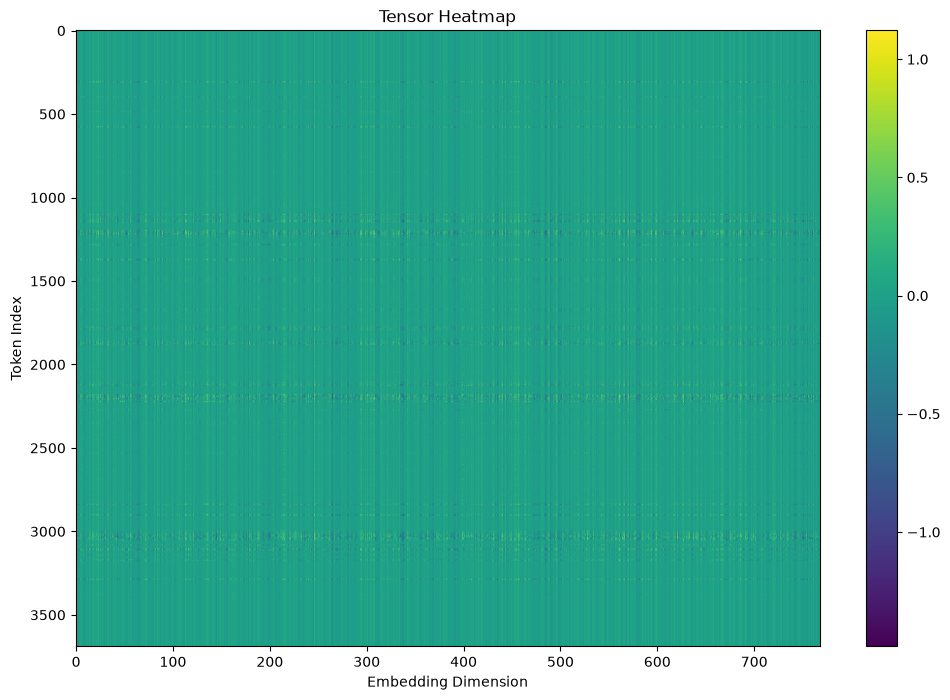

In [26]:
import matplotlib.pyplot as plt

matrix = x.squeeze(0).detach().cpu().numpy()

plt.figure(figsize=(12, 8))
plt.imshow(matrix, aspect="auto", cmap="viridis")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Index")
plt.title("Tensor Heatmap")
plt.colorbar()
plt.show()

In [27]:
import numpy as np

matrix = x.squeeze(0).detach().cpu().numpy()

print(matrix.shape)
# (3690, 768)

(3690, 768)


In [29]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 25.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 15.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(matrix)

print(embeddings_2d.shape)
# (3690, 2)

(3690, 2)


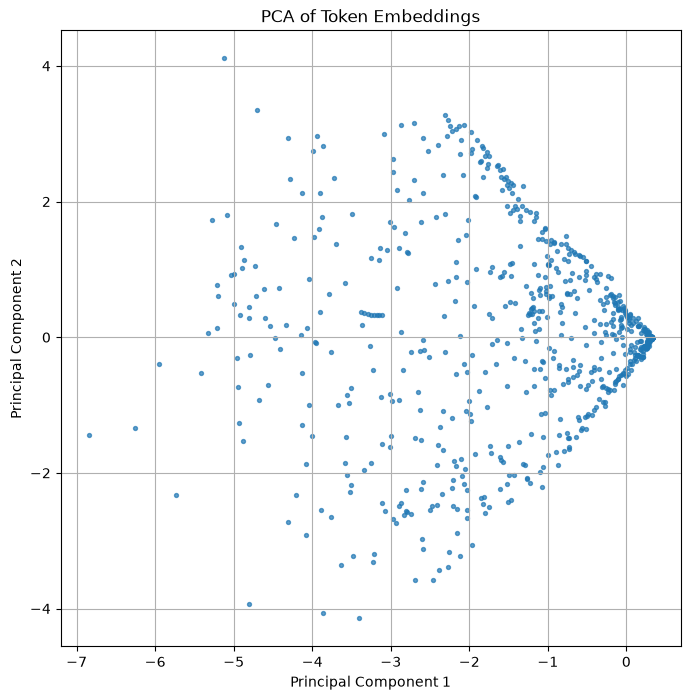

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    s=8,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Token Embeddings")
plt.grid(True)

plt.show()

In [3]:
import cv2
import torch
import numpy as np

NUM_FRAMES = 16
SIZE = 224

cap = cv2.VideoCapture("video.mp4")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

indices = np.linspace(
    0,
    total_frames - 1,
    NUM_FRAMES,
    dtype=int
)

frames = []

for frame_index in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

    ret, frame = cap.read()

    if not ret:
        continue

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (SIZE, SIZE))

    frames.append(frame)

cap.release()

video = torch.tensor(np.array(frames)).float() / 255.0

# [T, H, W, C] -> [C, T, H, W]
video = video.permute(3, 0, 1, 2)

# Add batch dimension
input = video.unsqueeze(0)

print(input.shape)

torch.Size([1, 3, 16, 224, 224])


In [7]:
from utils.patch_embed import PatchEmbed3D

patcher = PatchEmbed3D()
x = patcher(input)
print(x.shape)

torch.Size([1, 1568, 768])
